# 项目三：泰坦尼克号生存预测（第一次碰「脏数据」）

**目标**：根据乘客的性别、年龄、舱位等信息，预测他/她是否生还（1=生还，0=遇难）。

**这个项目和前两个最大的区别**：
- 数据是**真实的、脏的**：有缺失值、有文字（性别是 male/female）、有乱七八糟的列（船票号、姓名）
- 你要学会**数据清洗 + 特征工程**——这才是真实工作中 80% 的活，模型训练只占 20%

**你会学到**：
1. 处理缺失值（删掉、填中位数、填众数，各用在什么情况）
2. 把文字特征转成数字（编码）
3. 特征工程：从「姓名」里挖出有用的信息
4. 特征重要性：哪些信息最能预测生死

> 数据已经下载好在同目录下的 `titanic.csv`，直接跑就行。

In [22]:
# 第 1 步：加载数据 + 看整体情况
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv("D:/machine_learning/titanic.csv")

print("形状:", df.shape)
print("\n各列缺失值数量（这一列有多少个空格）：")
print(df.isnull().sum())
print("\n前 3 行：")
df.head(3)

形状: (891, 12)

各列缺失值数量（这一列有多少个空格）：
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

前 3 行：


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 先认识每一列

| 列名 | 含义 | 类型 |
|---|---|---|
| `PassengerId` | 乘客编号（纯序号，没用） | 数字 |
| `Survived` | **是否生还（目标，要预测的）** | 0/1 |
| `Pclass` | 舱位等级（1/2/3，越小越豪华） | 数字 |
| `Name` | 姓名 | 文字 |
| `Sex` | 性别 | male/female |
| `Age` | 年龄（**缺 177 个**） | 数字 |
| `SibSp` | 同行的兄弟姐妹/配偶数 | 数字 |
| `Parch` | 同行的父母/子女人数 | 数字 |
| `Ticket` | 船票号（没用） | 文字 |
| `Fare` | 票价 | 数字 |
| `Cabin` | 客舱号（**缺 687 个，77% 都缺**） | 文字 |
| `Embarked` | 登船港口（S/C/Q，**缺 2 个**） | 文字 |

**关键观察**：`Survived` 这一列没有缺失（我们有权用），`Age` 和 `Cabin` 缺得最多。

In [23]:
# 第 2 步：先探索——「谁更容易生还」
# 这步很重要：它告诉你哪些特征有用，是后面特征工程的依据

print("不同性别的生存率（1=生还）：")
print(df.groupby("Sex")["Survived"].mean())

print("\n不同舱位等级的生存率：")
print(df.groupby("Pclass")["Survived"].mean())

print("\n不同登船港口的生存率：")
print(df.groupby("Embarked")["Survived"].mean())

不同性别的生存率（1=生还）：
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

不同舱位等级的生存率：
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

不同登船港口的生存率：
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


## 处理缺失值：三种情况，三种做法

- **缺失很少（Embarked 缺 2 个）** → 用「众数」（出现最多的值）填
- **缺失一些（Age 缺 177 个）** → 用「中位数」填（为什么不是平均数？中位数不怕极端值，比如有个 80 岁老头不会把平均值带偏）
- **缺失太多（Cabin 缺 687 个）** → 填也没意义，直接**删掉整列**

In [24]:
# 第 3 步：处理缺失值

# 1. Age 缺 177 个 → 用中位数填
df["Age"] = df["Age"].fillna(df["Age"].mean())

# 2. Embarked 缺 2 个 → 用众数填（mode()[0] 是出现最多的那个值）
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# 3. Cabin 缺 687 个（77%）→ 直接删掉这一列
df = df.drop(columns=["Cabin"])

print("处理完后再检查，应该全是 0：")
print(df.isnull().sum())

处理完后再检查，应该全是 0：
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 把文字转成数字（编码）

模型（逻辑回归、随机森林）**只认识数字**，不认识 `"male"`、`"female"` 这种文字。

所以要「编码」：`male → 0`，`female → 1`。这个过程叫 **类别编码**。

In [25]:
# 第 4 步：类别编码

# Sex 只有两个值，直接映射成 0/1
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Embarked 有三个值 S/C/Q，映射成 0/1/2
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

print("编码后的 Sex 和 Embarked：")
df[["Sex", "Embarked"]].head(8)

编码后的 Sex 和 Embarked：


,Sex,Embarked
0,0,0
1,1,1
2,1,0
3,1,0
4,0,0
5,0,2
6,0,0
7,0,0


## 特征工程：从「姓名」里挖宝藏

`Name` 这一列看起来没用，但仔细看：`Braund, Mr. Owen Harris` 里藏着 **`Mr.`（称谓）**。

称谓和生存率强相关：`Miss`（未婚小姐）大多生还，`Mr`（先生）大多遇难。所以我们把称谓提取出来，变成一个新特征。

**这就是「特征工程」的精髓：从看似无用的数据里，造出有用的特征。**

In [26]:
# 第 5 步：特征工程

# 用正则从姓名里抓出称谓（逗号后面那个词 + 句点）
df["Title"] = df["Name"].str.extract(r",\s*(\w+)\.", expand=False)

# 看各种称谓的生存率，验证一下这个特征有没有用
print("各称谓的生存率：")
print(df.groupby("Title")["Survived"].agg(["count", "mean"]))


各称谓的生存率：
          count      mean
Title                    
Capt          1  0.000000
Col           2  0.500000
Don           1  0.000000
Dr            7  0.428571
Jonkheer      1  0.000000
Lady          1  1.000000
Major         2  0.500000
Master       40  0.575000
Miss        182  0.697802
Mlle          2  1.000000
Mme           1  1.000000
Mr          517  0.156673
Mrs         125  0.792000
Ms            1  1.000000
Rev           6  0.000000
Sir           1  1.000000


In [27]:
# 把乱七八糟的称谓归成几大类
df["Title"] = df["Title"].replace(["Mlle", "Ms"], "Miss")                       # 未婚女性都归 Miss
df["Title"] = df["Title"].replace(["Mme", "Lady", "Countess"], "Mrs")           # 已婚/贵妇归 Mrs
df["Title"] = df["Title"].replace(
    ["Don", "Rev", "Dr", "Major", "Sir", "Col", "Capt", "Jonkheer"], "Other"
)   # 罕见称谓归 Other

# 再转成数字（编码）
df["Title"] = df["Title"].map({"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3, "Other": 4}).fillna(4)

# 家庭大小 = 兄弟姐妹/配偶 + 父母/子女 + 自己
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 是否独自一人（独行的人可能更容易遇难）
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print("特征工程完成，新增了 Title、FamilySize、IsAlone 三列")
print("\n现在的列：", list(df.columns))

特征工程完成，新增了 Title、FamilySize、IsAlone 三列

现在的列： ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone']


## 特征选择 + 训练

现在把所有有用的特征挑出来，丢掉没用的（`PassengerId`、`Name`、`Ticket`）。

In [31]:
# 第 6 步：选定特征 + 划分训练/测试集
features = ["Pclass", "Sex"]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("训练集:", X_train.shape, " 测试集:", X_test.shape)

训练集: (712, 2)  测试集: (179, 2)


In [33]:
# 第 7 步：训练逻辑回归
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"逻辑回归准确率: {accuracy_score(y_test, y_pred):.2%}")

逻辑回归准确率: 78.21%


随机森林准确率: 76.54%

特征重要性排名（从高到低）：
Sex       0.73243
Pclass    0.26757
dtype: float64


c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\machine_learning\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: G

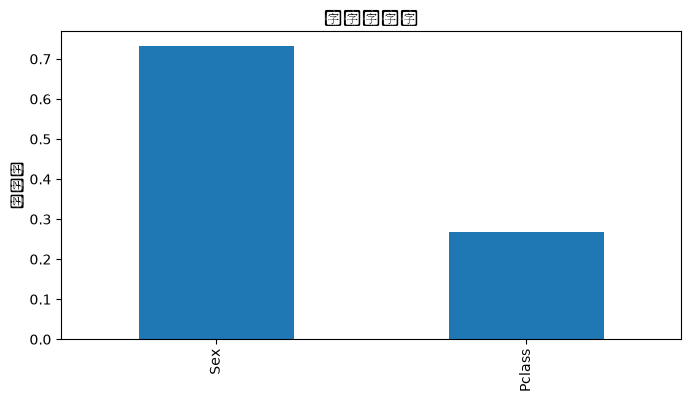

In [32]:
# 第 8 步：换随机森林，并看「特征重要性」
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"随机森林准确率: {accuracy_score(y_test, rf_pred):.2%}")

# 特征重要性：哪个特征对预测「生还」最有用
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\n特征重要性排名（从高到低）：")
print(importances)

importances.plot(kind="bar", figsize=(8, 4))
plt.title("特征重要性")
plt.ylabel("重要性")
plt.show()

## 自己动手改（练习）

1. 看特征重要性排名，**哪个特征最有用？** 回到第 2 步的探索结果，能对上吗？（比如 Sex 的生存率差异最大，它是不是最重要？）
2. **删掉 `Title` 特征**（在 features 列表里去掉 "Title"），准确率怎么变？体会特征工程的作用。
3. 把 Age 的填充方式改成**平均数** `df["Age"].fillna(df["Age"].mean())`，准确率有变化吗？为什么中位数通常更稳？
4. 试试**只用 Sex 和 Pclass 两个特征**（features = ["Sex", "Pclass"]），准确率是多少？——你会发现「少而精」的特征，有时和一堆特征效果差不多。

**核心体会**：这个项目里你花在「洗数据、造特征」上的时间，远多于「训练模型」。这就是真实机器学习的日常。